# Transformer Resource Accounting

In [82]:
from dataclasses import dataclass

from cs336_basics.model.transformer_lm import TransformerLanguageModel

@dataclass
class TransformerConfig:
    vocab_size: int
    context_length: int
    num_layers: int
    d_model: int
    num_heads: int
    d_ff: int

    def __post_init__(self):
        self.model = TransformerLanguageModel(
            vocab_size=self.vocab_size,
            context_length=self.context_length,
            d_model=self.d_model,
            num_layers=self.num_layers,
            num_heads=self.num_heads,
            d_ff=self.d_ff,
        )

    def count_params(self):
        return {
            'all_params': sum(
                p.numel()
                for p in self.model.parameters()
            ),
            'trainable_params': sum(
                p.numel()
                for p in self.model.parameters()
                if p.requires_grad
            )
        }

In [83]:
gpt2_small = TransformerConfig(
    vocab_size=50257,
    context_length=1024,
    num_layers=12,
    d_model=768,
    num_heads=12,
    d_ff=4288,
)

In [84]:
params_count = gpt2_small.count_params()

In [ ]:
from collections import Counter

@dataclass
class FlopsCountingNode:
    name: str
    children: list['FlopsCountingNode'] | None = None
    flops: int = 0
    
    def count(self):
        return self.flops + (
            sum(c.count() for c in self.children)
            if self.children else 0
        )
    
    def breakdown(self):
        '''Generates flops breakdown for this node's subtree.'''
        result = {
            self.name: self.flops
        }
        if self.children:
            for i, child in enumerate(self.children):
                result[f'{child.name}[{i}]'] = child.count()
        return result

    @classmethod
    def create_input_embedding(cls, config: TransformerConfig)\
        -> 'FlopsCountingNode':
        # We use torch.gather without materializing token indices
        # to onehot encoding, so input embedding layer becomes a
        # lookup with 0 FLOPs.
        flops = 0
        return cls(
            name='InputEmbedding',
            flops=flops,
        )
    
    @classmethod
    def create_rms_norm(cls, config: TransformerConfig)\
        -> 'FlopsCountingNode':
        flops = (
            2 
            * config.context_length 
            * config.d_model
        )
        return cls(
            name='RmsNorm',
            flops=flops,
        )

    @classmethod
    def create_rope(cls, config: TransformerConfig)\
        -> 'FlopsCountingNode':
        # input x is (... seq dk), rot mat is (dk dk)
        d_k = config.d_model // config.num_heads
        flops = 2 * config.context_length * d_k
        return cls(
            name='RotaryPositionalEmbedding',
            flops=flops,
        )
    
    @classmethod
    def create_single_head_linear_layer(
        cls, config: TransformerConfig)\
        -> 'FlopsCountingNode':
        # Applicable to single head q, k, and v layers.
        # While attention don't require same dimensions for
        # k, q, v, for transformer lm we often make them
        # align for simplicity and hardware efficiency.
        d_k = config.d_model // config.num_heads
        flops = 2 * config.context_length * config.d_model * d_k
        return cls(
            name='SingleHeadLinear',
            flops = flops,
        )
    
    @classmethod
    def create_mha_output_layer(
        cls, config: TransformerConfig) \
        -> 'FlopsCountingNode':
        return cls(
            name='MhaOutput',
            flops=(
                2
                * config.context_length
                * config.d_model
                * config.d_model),
        )

    @classmethod
    def create_mha(cls, config: TransformerConfig)\
        -> 'FlopsCountingNode':
        def single_head_scaled_dot_product_attention_flops():
            # While scaled dot product attention doesn't
            # require same dimensions for Q, K, and V
            # matrices, in transformer LM they often match.
            queries = config.context_length
            keys = config.context_length
            d_k = config.d_model // config.num_heads
            d_v = d_k

            qk_flops = 2 * queries * keys * d_k
            softmax_v_flops = 2 * queries * keys * d_v

            return qk_flops + softmax_v_flops
        
        attention_flops = single_head_scaled_dot_product_attention_flops()\
            * config.num_heads
        return cls(
            name='MultiHeadAttention',
            flops=attention_flops,
            children=[
                cls.create_rope(config),
            ] + [
                cls.create_single_head_linear_layer(config)
                # multiply by 3 to account for q k v
                for _ in range(config.num_heads * 3)
            ] + [
                cls.create_mha_output_layer(config)
            ],
        )
    
    @classmethod
    def create_positionwise_ffn_w1_layer(cls, config: TransformerConfig)\
        -> 'FlopsCountingNode':
        return cls(
            name='SiluW1',
            # input.shape = (batch seq d_model)
            # w1.shape = (batch d_model d_ff)
            flops=2 * config.d_model * config.d_ff * config.context_length,
        )
    
    @classmethod
    def create_positionwise_ffn_w2_layer(cls, config: TransformerConfig)\
        -> 'FlopsCountingNode':
        return cls(
            name='SiluW2',
            # input.shape = (batch seq d_ff)
            # w2.shape = (batch d_ff d_model)
            flops=2 * config.d_model * config.d_ff * config.context_length,
        )
    
    @classmethod
    def create_positionwise_ffn_w3_layer(cls, config: TransformerConfig)\
        -> 'FlopsCountingNode':
        return cls(
            name='SiluW3',
            # input.shape = (batch seq d_model)
            # w3.shape = (batch d_model d_ff)
            flops=2 * config.d_model * config.d_ff * config.context_length,
        )

    @classmethod
    def create_swiglu_ffn(cls, config: TransformerConfig)\
        -> 'FlopsCountingNode':
        # NOTE: this is the MOST EXPENSIVE layer flops-wise.
        return cls(
            name='PositionwiseFeedforward',
            children=[
                cls.create_positionwise_ffn_w1_layer(config),
                cls.create_positionwise_ffn_w2_layer(config),
                cls.create_positionwise_ffn_w3_layer(config),
            ]
        )

    @classmethod
    def create_transformer_block(cls, config: TransformerConfig)\
        -> 'FlopsCountingNode':
        return cls(
            name='TransformerBlock',
            children=[
                cls.create_rms_norm(config),
                cls.create_mha(config),
                cls.create_rms_norm(config),
                cls.create_swiglu_ffn(config),
            ]
        )

    @classmethod
    def create_output_embedding(cls, config: TransformerConfig)\
        -> 'FlopsCountingNode':
        return cls(
            name='OutputEmbedding',
            flops=(
                2
                * config.context_length
                * config.vocab_size
                * config.d_model),
        )

    @classmethod
    def create_transformer_llm(cls, config: TransformerConfig)\
        -> 'FlopsCountingNode':
        return cls(
            name='TransformerLanguageModel',
            children=[
                cls.create_input_embedding(config),
            ] + [
                cls.create_transformer_block(config)
                for _ in range(config.num_layers)
            ] + [
                cls.create_rms_norm(config),
                cls.create_output_embedding(config),
            ],
        )

def create_llm_accounting_node(config: TransformerConfig)\
    -> FlopsCountingNode:
    '''Factory method to create root accounting node.'''
    return FlopsCountingNode.create_transformer_llm(config)

In [86]:
gpt2_small_accounting_node =\
    create_llm_accounting_node(gpt2_small)

print(f'gpt2 small model total flops: {gpt2_small_accounting_node.count()}')

gpt2 small model total flops: 418524954624


In [87]:
gpt2_medium = TransformerConfig(
    vocab_size=50257,
    context_length=1024,
    num_layers=24,
    d_model=1024,
    num_heads=16,
    d_ff=4288,
)

In [88]:
gpt2_large = TransformerConfig(
    vocab_size=50257,
    context_length=1024,
    num_layers=36,
    d_model=1280,
    num_heads=20,
    d_ff=4288,
)

In [89]:
gpt2_xl = TransformerConfig(
    vocab_size=50257,
    context_length=1024,
    num_layers=48,
    d_model=1600,
    num_heads=25,
    d_ff=4288,
)

## Trainable parameters count

In [90]:
params_count = {
    'gpt2_small': gpt2_small.count_params()['trainable_params'],
    'gpt2_medium': gpt2_medium.count_params()['trainable_params'],
    'gpt2_large': gpt2_large.count_params()['trainable_params'],
    'gpt2_xl': gpt2_xl.count_params()['trainable_params'],
}

In [91]:
params_count

{'gpt2_small': 224080128,
 'gpt2_medium': 519785472,
 'gpt2_large': 957454080,
 'gpt2_xl': 1640452800}

In [92]:
import matplotlib.pyplot as plt

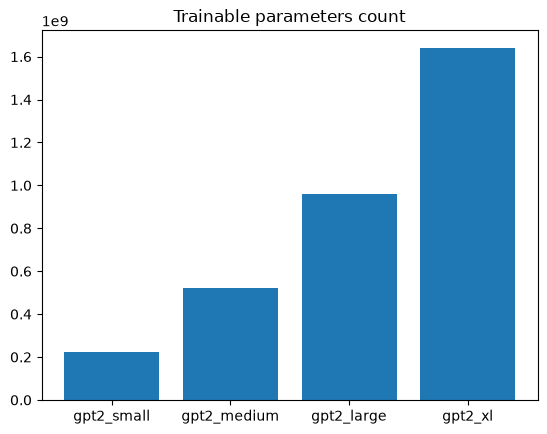

In [93]:
%matplotlib inline
plt.bar(params_count.keys(), params_count.values())
plt.title('Trainable parameters count')
plt.show()

## FLOPs count

In [94]:
flops_count = {
    'gpt2_small': create_llm_accounting_node(gpt2_small).count(),
    'gpt2_medium': create_llm_accounting_node(gpt2_medium).count(),
    'gpt2_large': create_llm_accounting_node(gpt2_large).count(),
    'gpt2_xl': create_llm_accounting_node(gpt2_xl).count(),
}

In [95]:
flops_count

{'gpt2_small': 418524954624,
 'gpt2_medium': 1062206439424,
 'gpt2_large': 2022398492672,
 'gpt2_xl': 3517094035456}

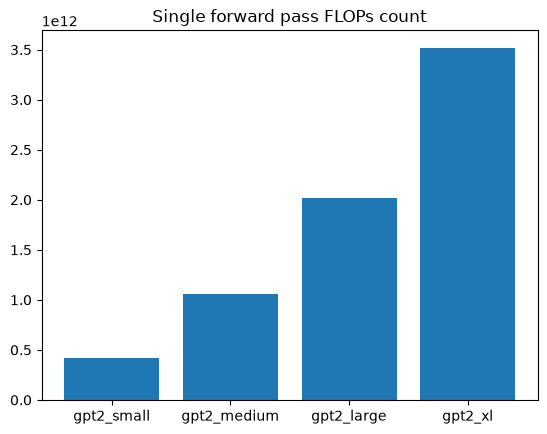

In [96]:
%matplotlib inline
plt.bar(flops_count.keys(), flops_count.values())
plt.title('Single forward pass FLOPs count')
plt.show()

## Flops breakdown

In [97]:
gpt2_xl_node = create_llm_accounting_node(gpt2_xl)
root_breakdown = gpt2_xl_node.breakdown()

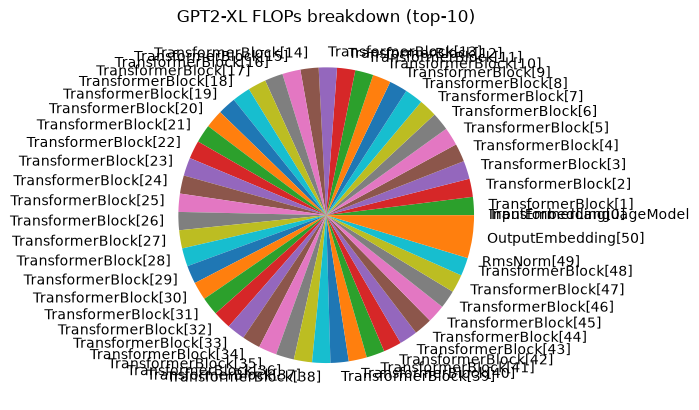

In [99]:
# Most expensive is output embedding, expected becase we need to
# map to vocab_size probabilities (O(50K) entries), from d_model
# embeddings (O(1K)), and context_length tokens (O(1K)). That's
# O(5e10) or 50B FLOPs In contrast, most other layers multiple by
# d_model instead of vocab_size, so that's 50x cheaper.

%matplotlib inline
plt.pie(root_breakdown.values(), labels=root_breakdown.keys())
plt.title('GPT2-XL FLOPs breakdown (top-10)')
plt.show()


In [100]:
def get_child(parent_node, child_name):
    if not parent_node.children:
        return None
    child_node = [
        child
        for child in parent_node.children
        if child.name.startswith(child_name)
    ][0]
    return child_node

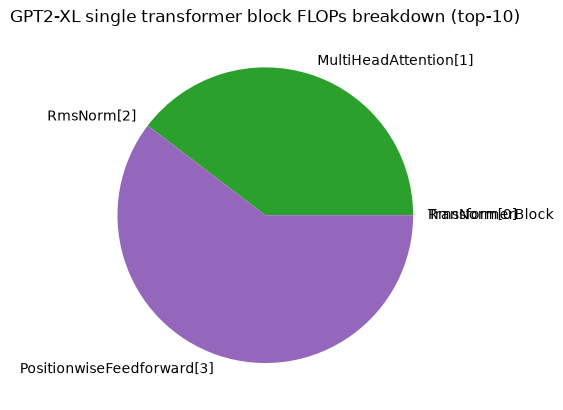

In [101]:
# Drill down into single transformer block.
#
# FFN is most expensive.
single_transformer_block_node = get_child(
    gpt2_xl_node,
    'TransformerBlock',
)

%matplotlib inline
plt.pie(single_transformer_block_node.breakdown().values(), labels=single_transformer_block_node.breakdown().keys())
plt.title('GPT2-XL single transformer block FLOPs breakdown (top-10)')
plt.show()

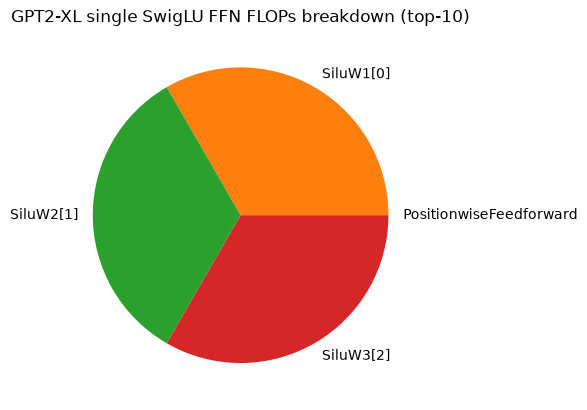

In [102]:
# Drill down into SwigLU FFN. Expectedly, each of the 3
# linear layer costs equally (they all have cost
# 2 * seq * d_model * d_ff).
swiglu_node = get_child(
    single_transformer_block_node,
    'PositionwiseFeedforward',
)

%matplotlib inline
plt.pie(swiglu_node.breakdown().values(), labels=swiglu_node.breakdown().keys())
plt.title('GPT2-XL single SwigLU FFN FLOPs breakdown (top-10)')
plt.show()

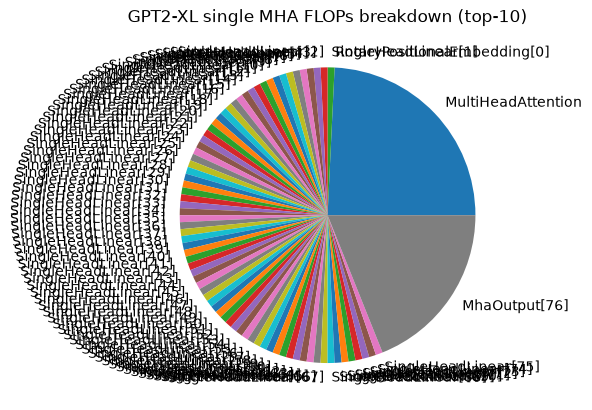

In [ ]:
# Drill down into multi-head attention block.
#
# Most costly portion are Q K V calculations for
# all heads combined (i.e. Qi = Wqi * x, for
# each head i). This also justifies why KV cache
# is effective at inference time. Side note: KV
# cache does NOT cache Q, because during inference
# we only incrementally calculate q *vector* to
# compute the next attention *vector* each time we
# advance 1 token step (whereas in training, we
# can parallelize the full Q matrix; though KV
# cache is not useful for training anyway). OTOH,
# caching K and V *matrices* (as Wki * x, Wvi * x)
# are reusable, because the prior computed sub-
# matrices are immutable and reusable for new
# query vector.
mha_node = get_child(
    single_transformer_block_node,
    'MultiHeadAttention',
)

%matplotlib inline
plt.pie(mha_node.breakdown().values(), labels=mha_node.breakdown().keys())
plt.title('GPT2-XL single MHA FLOPs breakdown (top-10)')
plt.show()